In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# CSV 로딩
df = pd.read_csv('ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv')

# SQLite DB 생성
conn = sqlite3.connect('hdb.db')

# 데이터 삽입
df.to_sql('hdb_resale', conn, if_exists='replace', index=False)

print("DB 생성 완료!")
print(f"총 {len(df):,}행 삽입")

# 테이블 구조 확인
result = pd.read_sql("PRAGMA table_info(hdb_resale)", conn)
print(result[['name', 'type']])

DB 생성 완료!
총 235,468행 삽입
                   name     type
0                 month     TEXT
1                  town     TEXT
2             flat_type     TEXT
3                 block     TEXT
4           street_name     TEXT
5          storey_range     TEXT
6        floor_area_sqm     REAL
7            flat_model     TEXT
8   lease_commence_date  INTEGER
9       remaining_lease     TEXT
10         resale_price     REAL


              town  avg_price  total_transactions  price_rank
0      BUKIT TIMAH   786863.0                 575           1
1           BISHAN   715577.0                4104           2
2     CENTRAL AREA   698973.0                1831           3
3       QUEENSTOWN   647330.0                6429           4
4      BUKIT MERAH   643770.0                8993           5
5  KALLANG/WHAMPOA   599180.0                7178           6
6        PASIR RIS   592219.0                6793           7
7        TOA PAYOH   581366.0                7724           8
8         TAMPINES   570993.0               16237           9
9        SERANGOON   569766.0                4143          10


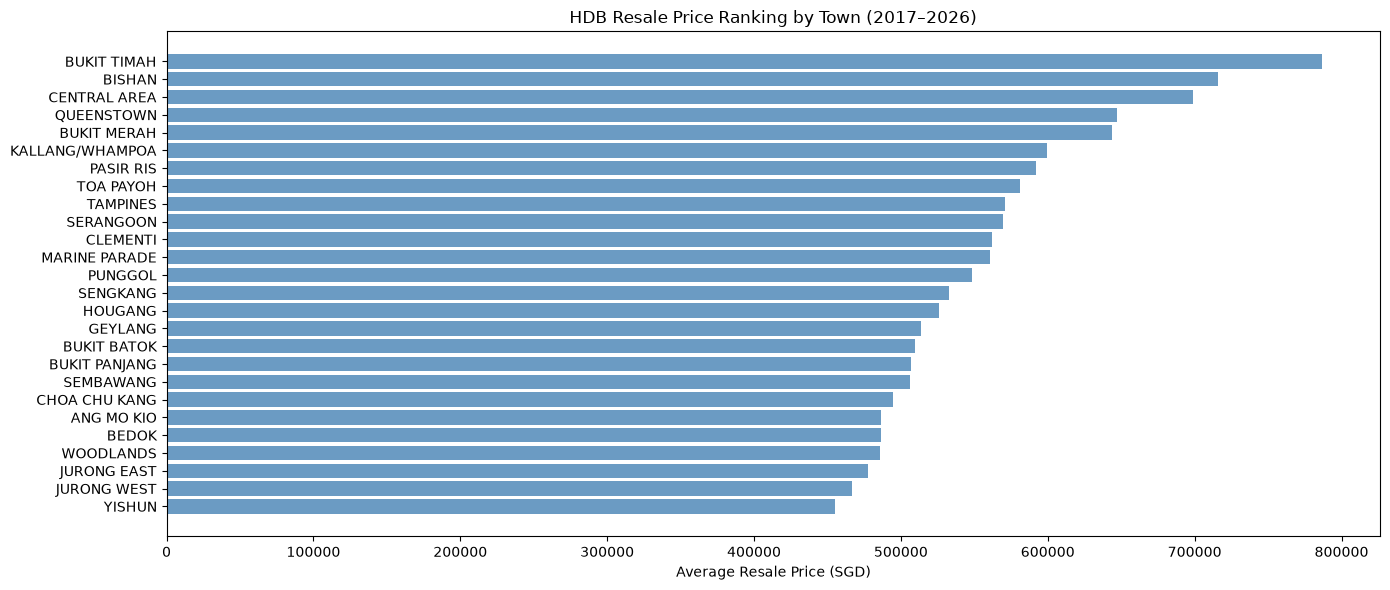

In [2]:
query1 = """
SELECT 
    town,
    ROUND(AVG(resale_price), 0) AS avg_price,
    COUNT(*) AS total_transactions,
    RANK() OVER (ORDER BY AVG(resale_price) DESC) AS price_rank
FROM hdb_resale
GROUP BY town
ORDER BY price_rank
"""

df1 = pd.read_sql(query1, conn)
print(df1.head(10))

# 시각화
plt.figure(figsize=(14, 6))
plt.barh(df1['town'][::-1], df1['avg_price'][::-1], color='steelblue', alpha=0.8)
plt.xlabel('Average Resale Price (SGD)')
plt.title('HDB Resale Price Ranking by Town (2017–2026)')
plt.tight_layout()
plt.savefig('fig_01_town_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

   year  avg_price  prev_year_price  yoy_growth_pct
0  2017   443889.0              NaN             NaN
1  2018   441282.0         443889.0            -0.6
2  2019   432138.0         441282.0            -2.1
3  2020   452279.0         432138.0             4.7
4  2021   511381.0         452279.0            13.1
5  2022   549714.0         511381.0             7.5
6  2023   571806.0         549714.0             4.0
7  2024   612597.0         571806.0             7.1
8  2025   652522.0         612597.0             6.5
9  2026   659989.0         652522.0             1.1


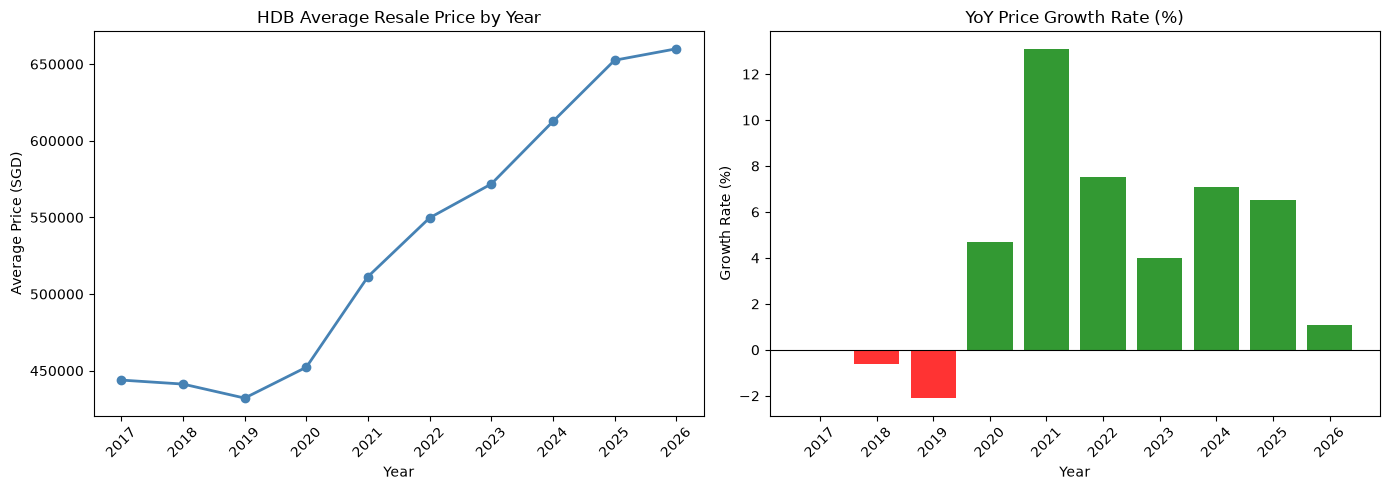

In [3]:
query2 = """
WITH yearly_avg AS (
    SELECT 
        SUBSTR(month, 1, 4) AS year,
        ROUND(AVG(resale_price), 0) AS avg_price
    FROM hdb_resale
    GROUP BY year
)
SELECT 
    year,
    avg_price,
    LAG(avg_price) OVER (ORDER BY year) AS prev_year_price,
    ROUND(
        (avg_price - LAG(avg_price) OVER (ORDER BY year)) 
        / LAG(avg_price) OVER (ORDER BY year) * 100, 1
    ) AS yoy_growth_pct
FROM yearly_avg
ORDER BY year
"""

df2 = pd.read_sql(query2, conn)
print(df2)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df2['year'], df2['avg_price'], marker='o', linewidth=2, color='steelblue')
axes[0].set_title('HDB Average Resale Price by Year')
axes[0].set_ylabel('Average Price (SGD)')
axes[0].set_xlabel('Year')
axes[0].tick_params(axis='x', rotation=45)

colors = ['green' if x > 0 else 'red' for x in df2['yoy_growth_pct'].fillna(0)]
axes[1].bar(df2['year'], df2['yoy_growth_pct'].fillna(0), color=colors, alpha=0.8)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_title('YoY Price Growth Rate (%)')
axes[1].set_ylabel('Growth Rate (%)')
axes[1].set_xlabel('Year')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig_02_yoy_growth.png', dpi=150, bbox_inches='tight')
plt.show()

          flat_type  transactions  avg_price  min_price  max_price
0            1 ROOM            87   214838.0   157000.0   300000.0
1            2 ROOM          4907   306109.0   150000.0   696000.0
2            3 ROOM         56049   377430.0   140000.0  1568000.0
3            4 ROOM         99998   537272.0   218000.0  1550000.0
4            5 ROOM         57596   632616.0   270000.0  1728000.0
5         EXECUTIVE         16743   740399.0   390000.0  1600000.0
6  MULTI-GENERATION            88   869441.0   600000.0  1388888.0


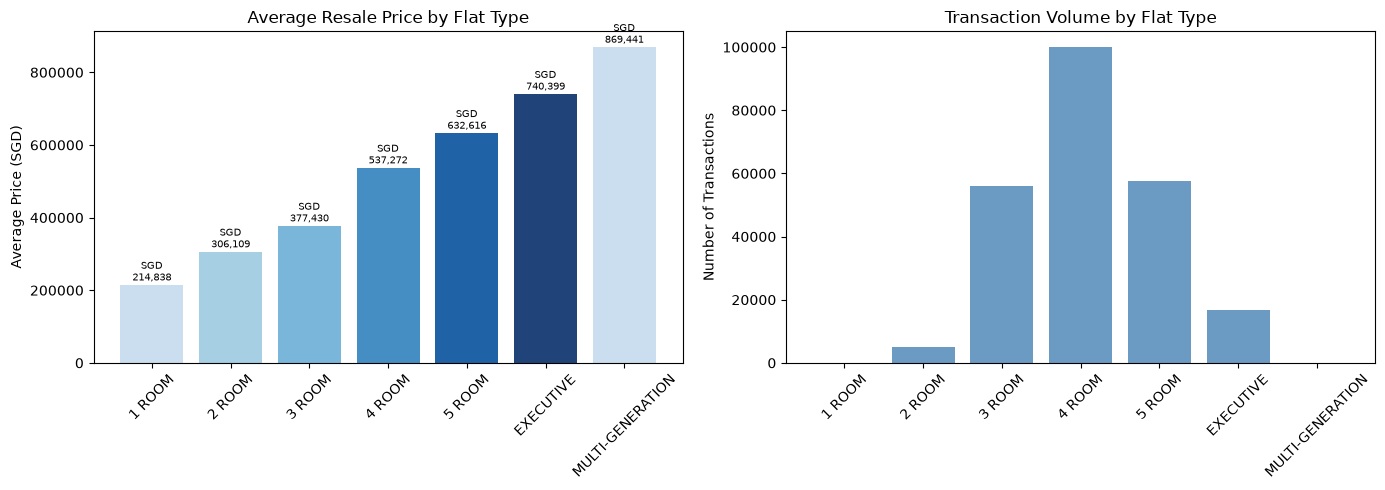

In [3]:
query3 = """
SELECT 
    flat_type,
    COUNT(*) AS transactions,
    ROUND(AVG(resale_price), 0) AS avg_price,
    ROUND(MIN(resale_price), 0) AS min_price,
    ROUND(MAX(resale_price), 0) AS max_price
FROM hdb_resale
GROUP BY flat_type
ORDER BY avg_price
"""

df3 = pd.read_sql(query3, conn)
print(df3)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#c6dbef', '#9ecae1', '#6baed6', '#3182bd', '#08519c', '#08306b']
bars = axes[0].bar(df3['flat_type'], df3['avg_price'], color=colors, alpha=0.9)
axes[0].set_title('Average Resale Price by Flat Type')
axes[0].set_ylabel('Average Price (SGD)')
axes[0].tick_params(axis='x', rotation=45)
for bar, price in zip(bars, df3['avg_price']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
                f'SGD\n{price:,.0f}', ha='center', va='bottom', fontsize=7)

axes[1].bar(df3['flat_type'], df3['transactions'], color='steelblue', alpha=0.8)
axes[1].set_title('Transaction Volume by Flat Type')
axes[1].set_ylabel('Number of Transactions')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig_03_flat_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

              town  avg_2020  avg_2024  growth_pct
0        TOA PAYOH  445228.0  664600.0        49.3
1        SEMBAWANG  396459.0  577054.0        45.6
2        WOODLANDS  400154.0  582175.0        45.5
3  KALLANG/WHAMPOA  484567.0  691279.0        42.7
4      BUKIT BATOK  403084.0  572601.0        42.1
5           YISHUN  383593.0  540941.0        41.0
6    CHOA CHU KANG  410019.0  574782.0        40.2
7          GEYLANG  438807.0  614531.0        40.0
8        PASIR RIS  504248.0  703588.0        39.5
9         SENGKANG  454810.0  633863.0        39.4


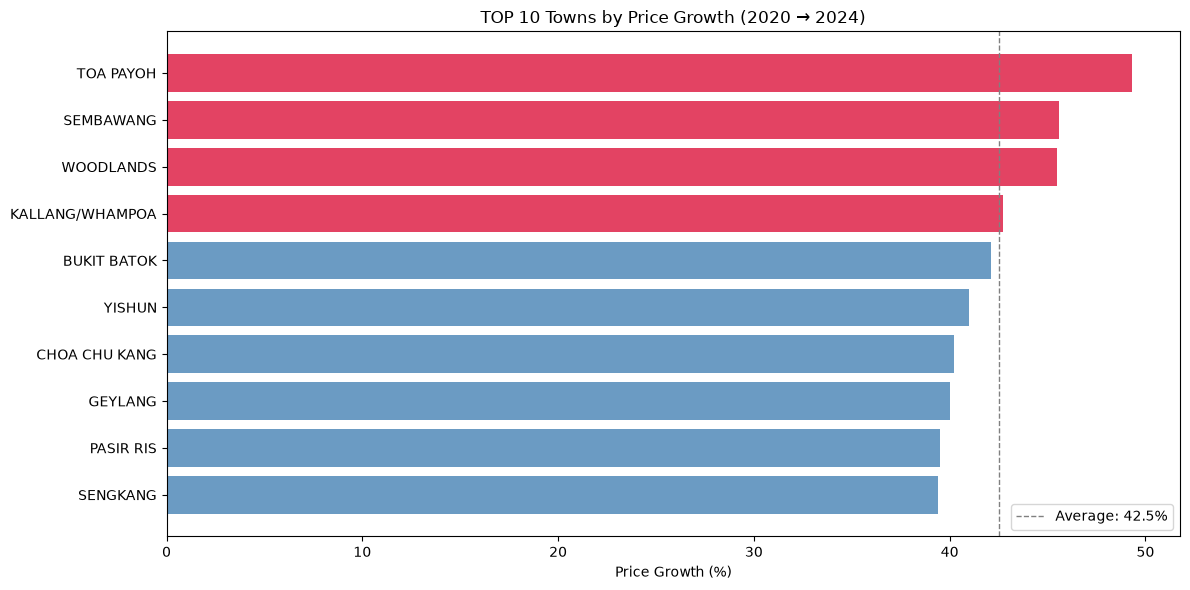

In [4]:
query4 = """
WITH price_2020 AS (
    SELECT town, ROUND(AVG(resale_price), 0) AS avg_2020
    FROM hdb_resale
    WHERE SUBSTR(month, 1, 4) = '2020'
    GROUP BY town
),
price_2024 AS (
    SELECT town, ROUND(AVG(resale_price), 0) AS avg_2024
    FROM hdb_resale
    WHERE SUBSTR(month, 1, 4) = '2024'
    GROUP BY town
)
SELECT 
    p20.town,
    p20.avg_2020,
    p24.avg_2024,
    ROUND((p24.avg_2024 - p20.avg_2020) / p20.avg_2020 * 100, 1) AS growth_pct
FROM price_2020 p20
JOIN price_2024 p24 ON p20.town = p24.town
ORDER BY growth_pct DESC
LIMIT 10
"""

df4 = pd.read_sql(query4, conn)
print(df4)

# 시각화
plt.figure(figsize=(12, 6))
colors = ['crimson' if x > df4['growth_pct'].mean() else 'steelblue' 
          for x in df4['growth_pct']]
bars = plt.barh(df4['town'][::-1], df4['growth_pct'][::-1], color=colors[::-1], alpha=0.8)
plt.axvline(x=df4['growth_pct'].mean(), color='gray', linestyle='--', 
            linewidth=1, label=f'Average: {df4["growth_pct"].mean():.1f}%')
plt.title('TOP 10 Towns by Price Growth (2020 → 2024)')
plt.xlabel('Price Growth (%)')
plt.legend()
plt.tight_layout()
plt.savefig('fig_04_top10_growth.png', dpi=150, bbox_inches='tight')
plt.show()

           period  total_transactions  avg_price  monthly_avg_transactions
0   1_Pre_Cooling              114254   458152.0                    1937.0
1  2_Cooling_2021               20242   542865.0                    2249.0
2  3_Cooling_2022               15565   560078.0                    2224.0
3  4_Cooling_2023               85407   623587.0                    2135.0


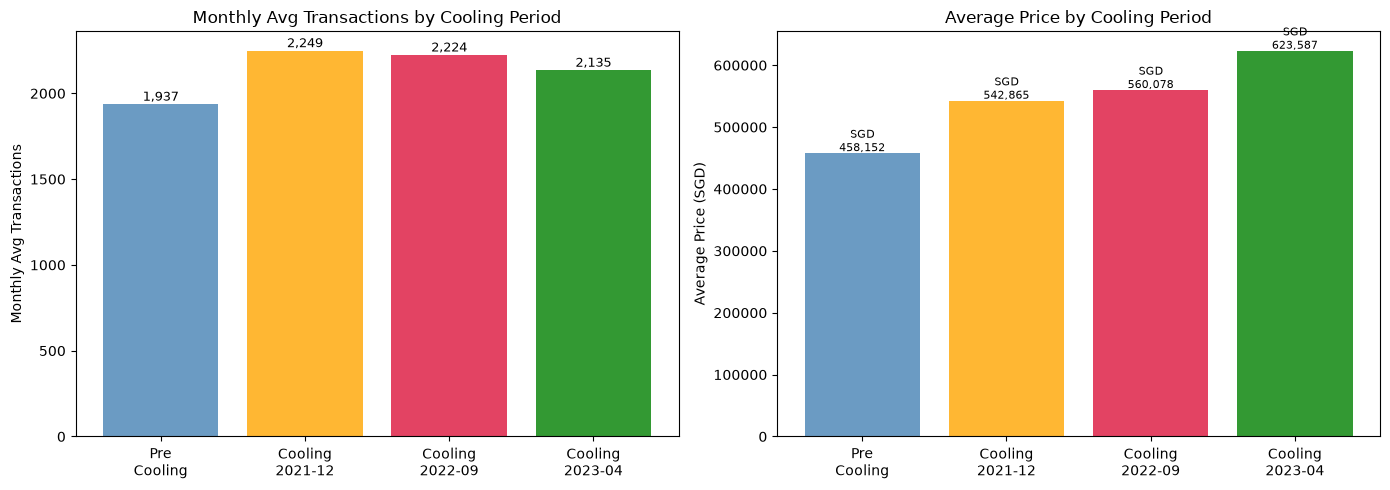

In [5]:
query5 = """
SELECT 
    CASE 
        WHEN month < '2021-12' THEN '1_Pre_Cooling'
        WHEN month < '2022-09' THEN '2_Cooling_2021'
        WHEN month < '2023-04' THEN '3_Cooling_2022'
        ELSE '4_Cooling_2023'
    END AS period,
    COUNT(*) AS total_transactions,
    ROUND(AVG(resale_price), 0) AS avg_price,
    ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT month), 0) AS monthly_avg_transactions
FROM hdb_resale
GROUP BY period
ORDER BY period
"""

df5 = pd.read_sql(query5, conn)
print(df5)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

period_labels = ['Pre\nCooling', 'Cooling\n2021-12', 'Cooling\n2022-09', 'Cooling\n2023-04']
colors = ['steelblue', 'orange', 'crimson', 'green']

axes[0].bar(period_labels, df5['monthly_avg_transactions'], color=colors, alpha=0.8)
axes[0].set_title('Monthly Avg Transactions by Cooling Period')
axes[0].set_ylabel('Monthly Avg Transactions')
for i, v in enumerate(df5['monthly_avg_transactions']):
    axes[0].text(i, v + 20, f'{v:,.0f}', ha='center', fontsize=9)

axes[1].bar(period_labels, df5['avg_price'], color=colors, alpha=0.8)
axes[1].set_title('Average Price by Cooling Period')
axes[1].set_ylabel('Average Price (SGD)')
for i, v in enumerate(df5['avg_price']):
    axes[1].text(i, v + 3000, f'SGD\n{v:,.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('fig_05_cooling_periods.png', dpi=150, bbox_inches='tight')
plt.show()